# US Accident Data Analysis and Preprocessing

## Introduction
This project demonstrates data cleaning, preprocessing, feature engineering, visualization, model evaluation, and deployment concepts using the US Accidents dataset.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

## Data Collection and Loading

In [2]:
df = pd.read_csv(r"C:\Users\admin\Downloads\Documents\dadp\US_Accidents_March23.csv")

In [3]:
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


### Interpretation
- Dataset contains road accident information, weather conditions, environmental factors, and accident severity.

In [4]:
df.shape

(7728394, 46)

### Interpretation
- Displays total rows and columns available in the dataset.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

### Interpretation
- Dataset contains both numerical and categorical variables with missing values.

In [6]:
df.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.728394e+06,7.728394e+06,7.728394e+06,4.325632e+06,4.325632e+06,7.728394e+06,7.564541e+06,5.729375e+06,7.554250e+06,7.587715e+06,7.551296e+06,7.157161e+06,5.524808e+06
mean,2.212384e+00,3.620119e+01,-9.470255e+01,3.626183e+01,-9.572557e+01,5.618423e-01,6.166329e+01,5.825105e+01,6.483104e+01,2.953899e+01,9.090376e+00,7.685490e+00,8.407210e-03
std,4.875313e-01,5.076079e+00,1.739176e+01,5.272905e+00,1.810793e+01,1.776811e+00,1.901365e+01,2.238983e+01,2.282097e+01,1.006190e+00,2.688316e+00,5.424983e+00,1.102246e-01
min,1.000000e+00,2.455480e+01,-1.246238e+02,2.456601e+01,-1.245457e+02,0.000000e+00,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,3.339963e+01,-1.172194e+02,3.346207e+01,-1.177543e+02,0.000000e+00,4.900000e+01,4.300000e+01,4.800000e+01,2.937000e+01,1.000000e+01,4.600000e+00,0.000000e+00
50%,2.000000e+00,3.582397e+01,-8.776662e+01,3.618349e+01,-8.802789e+01,3.000000e-02,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,4.008496e+01,-8.035368e+01,4.017892e+01,-8.024709e+01,4.640000e-01,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01,0.000000e+00
max,4.000000e+00,4.900220e+01,-6.711317e+01,4.907500e+01,-6.710924e+01,4.417500e+02,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01


### Interpretation
- Statistical summary helps understand data distribution and detect anomalies.

## Data Preprocessing

In [7]:
df.isnull().sum().sort_values(ascending=False)

End_Lng                  3402762
End_Lat                  3402762
Precipitation(in)        2203586
Wind_Chill(F)            1999019
Wind_Speed(mph)           571233
Visibility(mi)            177098
Wind_Direction            175206
Humidity(%)               174144
Weather_Condition         173459
Temperature(F)            163853
Pressure(in)              140679
Weather_Timestamp         120228
Sunrise_Sunset             23246
Civil_Twilight             23246
Astronomical_Twilight      23246
Nautical_Twilight          23246
Airport_Code               22635
Street                     10869
Timezone                    7808
Zipcode                     1915
City                         253
Description                    5
ID                             0
Distance(mi)                   0
Start_Lng                      0
Source                         0
Severity                       0
Start_Time                     0
End_Time                       0
Start_Lat                      0
County    

### Interpretation
- Missing values are present in weather and environmental attributes.

In [8]:
df = df[['Severity',
         'Start_Time',
         'Temperature(F)',
         'Humidity(%)',
         'Pressure(in)',
         'Visibility(mi)',
         'Wind_Speed(mph)',
         'Weather_Condition',
         'City',
         'State',
         'Sunrise_Sunset']]

In [9]:
df.drop_duplicates(inplace=True)

### Interpretation
- Duplicate records are removed to improve data quality.

In [10]:
df['Weather_Condition'] = df['Weather_Condition'].astype(str).str.strip()

df['City'] = df['City'].astype(str).str.title()

df['State'] = df['State'].astype(str).str.upper()

### Interpretation
- Inconsistent text formats are standardized for better analysis.

In [11]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed', errors='coerce')

In [12]:
df.dropna(subset=['Start_Time'], inplace=True)

In [13]:
df['Year'] = df['Start_Time'].dt.year
df['Month'] = df['Start_Time'].dt.month
df['Hour'] = df['Start_Time'].dt.hour
df['Day'] = df['Start_Time'].dt.day_name()

### Interpretation
- Feature engineering extracts useful time-related variables.

In [14]:
df['Temperature(F)'].fillna(df['Temperature(F)'].median(), inplace=True)

df['Humidity(%)'].fillna(df['Humidity(%)'].median(), inplace=True)

df['Pressure(in)'].fillna(df['Pressure(in)'].median(), inplace=True)

df['Visibility(mi)'].fillna(df['Visibility(mi)'].median(), inplace=True)

df['Wind_Speed(mph)'].fillna(df['Wind_Speed(mph)'].median(), inplace=True)

df['Weather_Condition'].fillna(df['Weather_Condition'].mode()[0], inplace=True)

df['Sunrise_Sunset'].fillna(df['Sunrise_Sunset'].mode()[0], inplace=True)

### Interpretation
- Median and mode imputation techniques are used to handle missing values.

In [15]:
df.isnull().sum()

Severity             0
Start_Time           0
Temperature(F)       0
Humidity(%)          0
Pressure(in)         0
Visibility(mi)       0
Wind_Speed(mph)      0
Weather_Condition    0
City                 0
State                0
Sunrise_Sunset       0
Year                 0
Month                0
Hour                 0
Day                  0
dtype: int64

### Interpretation
- Confirms successful handling of missing values.

In [16]:
Q1 = df['Temperature(F)'].quantile(0.25)
Q3 = df['Temperature(F)'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['Temperature(F)'] >= lower) & (df['Temperature(F)'] <= upper)]

### Interpretation
- IQR method removes extreme outliers from temperature values.

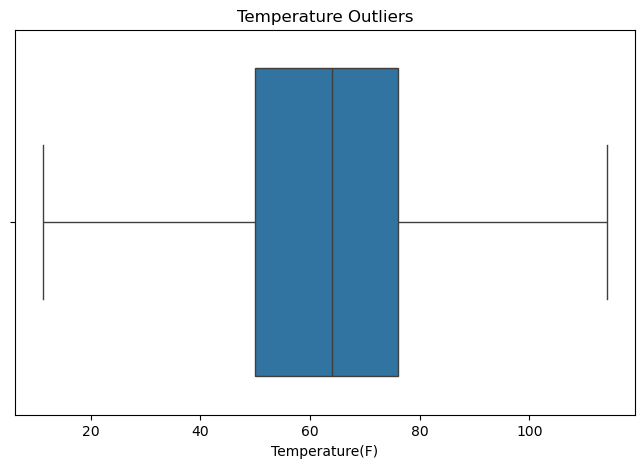

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Temperature(F)'])

plt.title("Temperature Outliers")

plt.show()

### Interpretation
- Boxplot visualizes remaining outliers after preprocessing.

## Handling Categorical Data

In [18]:
encoder = LabelEncoder()

df['Weather_Condition'] = encoder.fit_transform(df['Weather_Condition'])

df['City'] = encoder.fit_transform(df['City'])

df['State'] = encoder.fit_transform(df['State'])

df['Sunrise_Sunset'] = encoder.fit_transform(df['Sunrise_Sunset'])

df['Day'] = encoder.fit_transform(df['Day'])

### Interpretation
- Categorical variables are converted into numerical form using Label Encoding.

## Scaling and Transformation

In [19]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df.select_dtypes(include=np.number))

### Interpretation
- Standardization scales features to improve analytical performance.

## Data Visualization (EDA)

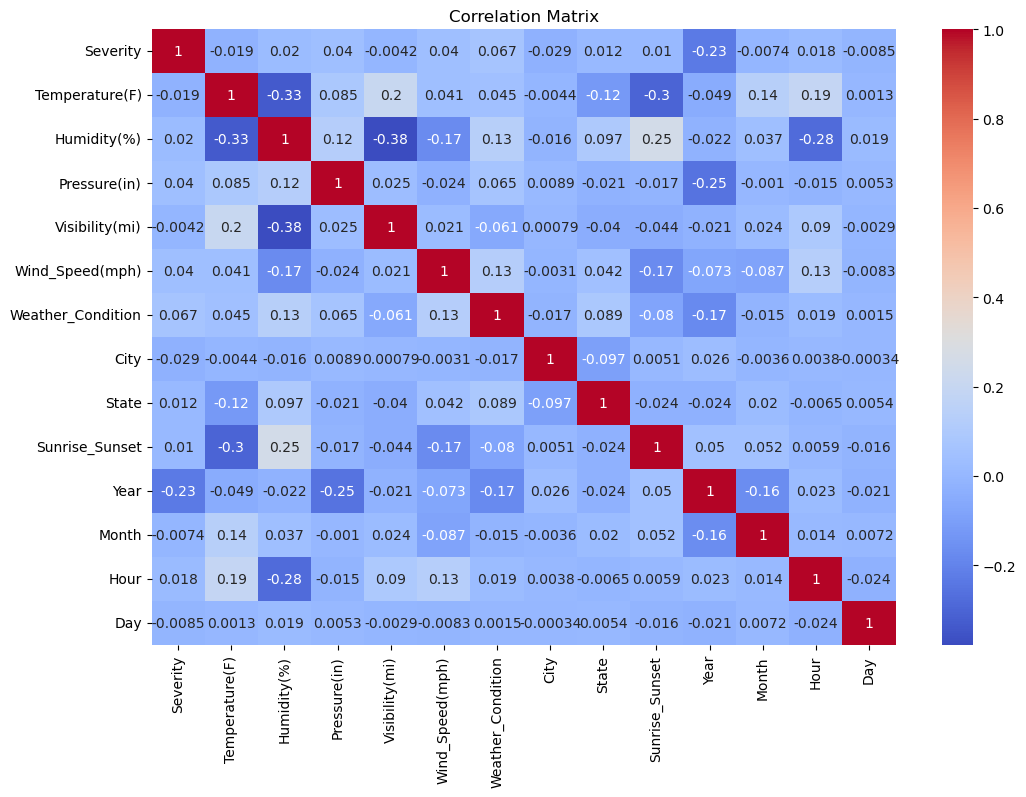

In [20]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

### Interpretation
- Correlation matrix identifies relationships among variables.

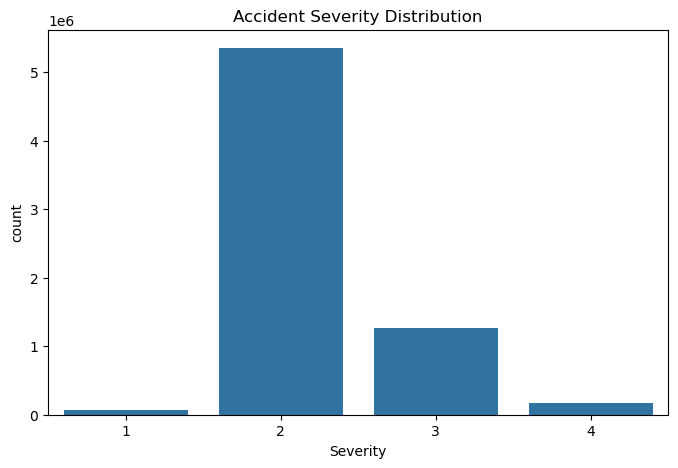

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(x='Severity', data=df)

plt.title("Accident Severity Distribution")

plt.show()

### Interpretation
- Severity distribution shows occurrence frequency of accident classes.

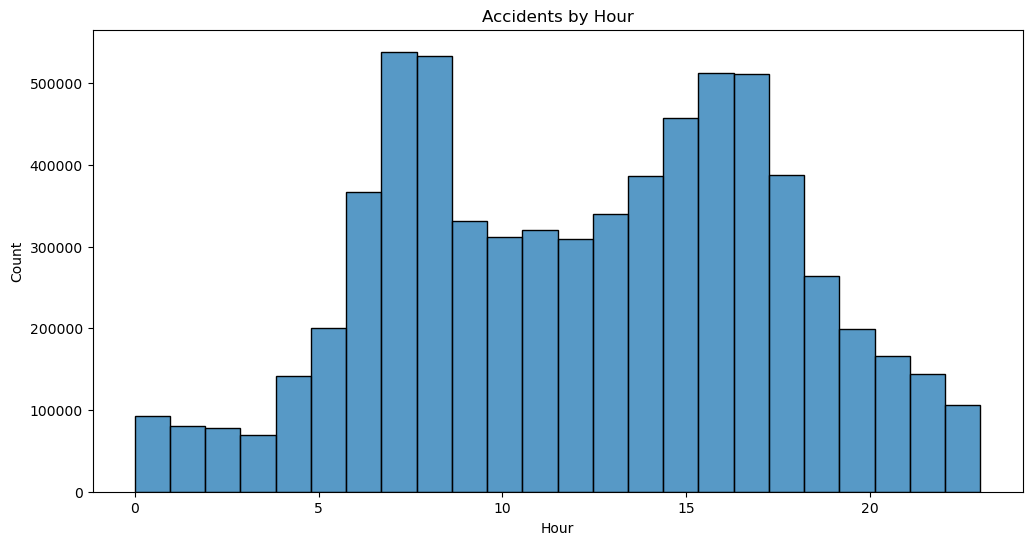

In [22]:
plt.figure(figsize=(12,6))

sns.histplot(df['Hour'], bins=24)

plt.title("Accidents by Hour")

plt.show()

### Interpretation
- Accident occurrences increase during peak traffic hours.

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(x='Severity',
            y='Visibility(mi)',
            data=df)

plt.title("Severity vs Visibility")

plt.show()

### Interpretation
- Poor visibility contributes to higher accident severity.

### Interpretation
- Pairplot displays multivariate relationships between numerical variables.

In [ ]:
pivot = pd.pivot_table(df,
                       values='Severity',
                       index='Month',
                       columns='Sunrise_Sunset',
                       aggfunc=np.mean)

pivot

### Interpretation
- Average severity varies across months and day/night conditions.

In [ ]:
pd.crosstab(df['Severity'], df['Sunrise_Sunset'])

### Interpretation
- Cross-tabulation shows association between severity and day/night.

In [ ]:
fig = px.scatter(df,
                 x='Temperature(F)',
                 y='Visibility(mi)',
                 color='Severity')

fig.show()

### Interpretation
- Interactive visualization improves understanding of environmental factors.

## PCA Without Library

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

X_pca = numeric_df.values

In [ ]:
mean = np.mean(X_pca, axis=0)

X_centered = X_pca - mean

In [ ]:
cov_matrix = np.cov(X_centered, rowvar=False)

cov_matrix

In [ ]:
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

In [ ]:
sorted_index = np.argsort(eigen_values)[::-1]

sorted_eigenvalues = eigen_values[sorted_index]

sorted_eigenvectors = eigen_vectors[:, sorted_index]

In [ ]:
n_components = 2

eigenvector_subset = sorted_eigenvectors[:, 0:n_components]

In [ ]:
X_reduced = np.dot(X_centered, eigenvector_subset)

pca_df = pd.DataFrame(X_reduced, columns=['PC1', 'PC2'])

pca_df.head()

### Interpretation
- PCA reduces dimensionality while preserving important information.

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(x='PC1',
                y='PC2',
                data=pca_df)

plt.title("PCA Without Library")

plt.show()

### Interpretation
- PCA visualization represents accident patterns in reduced dimensions.

## Model Evaluation

In [ ]:
X = df.drop('Severity', axis=1)

X = X.select_dtypes(include=np.number)

y = df['Severity']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

### Interpretation
- Logistic Regression evaluates the effectiveness of preprocessing and feature engineering.

## Conclusion

- Data cleaning, preprocessing, visualization, feature engineering, and model evaluation were successfully performed.
- Missing values, duplicates, inconsistencies, and outliers were handled effectively.
- PCA reduced dimensionality for visualization and analysis.
- Weather and visibility conditions significantly affect accident severity.
- The project demonstrates a complete data preprocessing workflow for real-world datasets.